In [4]:
%%capture
## [TEMPLATE BEGIN]
## おまじない：実行中のノートブック名からOUTPUT_DIRを決めるコード
from pathlib import Path
from IPython import get_ipython; ip = get_ipython()
if '__vsc_ipynb_file__' in ip.user_ns:
    ## VS Codeで実行されている場合
    THIS_NOTEBOOK_PATH = Path(ip.user_ns['__vsc_ipynb_file__'])
else:
    !pip install ipynbname
    import ipynbname; THIS_NOTEBOOK_PATH = Path(ipynbname.path())
    if "%2F" in THIS_NOTEBOOK_PATH.stem:
        ## Google Colabで実行されている場合
        colab_ip = %system hostname -I   # uses colab magic to get list from bash
        colab_ip = colab_ip[0].strip()   # returns "172.28.0.12"
        colab_port = 9000                # could use 6000, 8080, or 9000
        import requests
        filename = requests.get(f"http://{colab_ip}:{colab_port}/api/sessions").json()[0]["name"]
        THIS_NOTEBOOK_PATH = Path(filename)
    else:
        ## それ以外の場合
        THIS_NOTEBOOK_PATH = THIS_NOTEBOOK_PATH

OUTPUT_DIR = Path("figures") / THIS_NOTEBOOK_PATH.stem
## [TEMPLATE END]

In [8]:
print("File output directory:", OUTPUT_DIR)
# Create the output directory if it does not exist
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Install necessary packages
!pip install scipy scikit-learn matplotlib tqdm

File output directory: figures/_hyperparameter_search
  Obtaining dependency information for tqdm from https://files.pythonhosted.org/packages/48/5d/acf5905c36149bbaec41ccf7f2b68814647347b72075ac0b1fe3022fdc73/tqdm-4.66.5-py3-none-any.whl.metadata
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.6/57.6 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 4.3 MB/s eta 0:00:00

[notice] A new release of pip is available: 23.2.1 -> 24.2
[notice] To update, run: pip install --upgrade pip


/Users/teshima/lecture-supplement-material/Introduction-to-AI/.venv/lib/python3.11/site-packages/scipy/stats/_qmc.py:958: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  sample = self._random(n, workers=workers)
Evaluating Hyperparameters: 100%|██████████| 50/50 [00:12<00:00,  4.12it/s]


Best Parameters: {'n_estimators': 105, 'max_depth': 11, 'min_samples_split': 6}
Best Cross-Validation Score: 0.9667


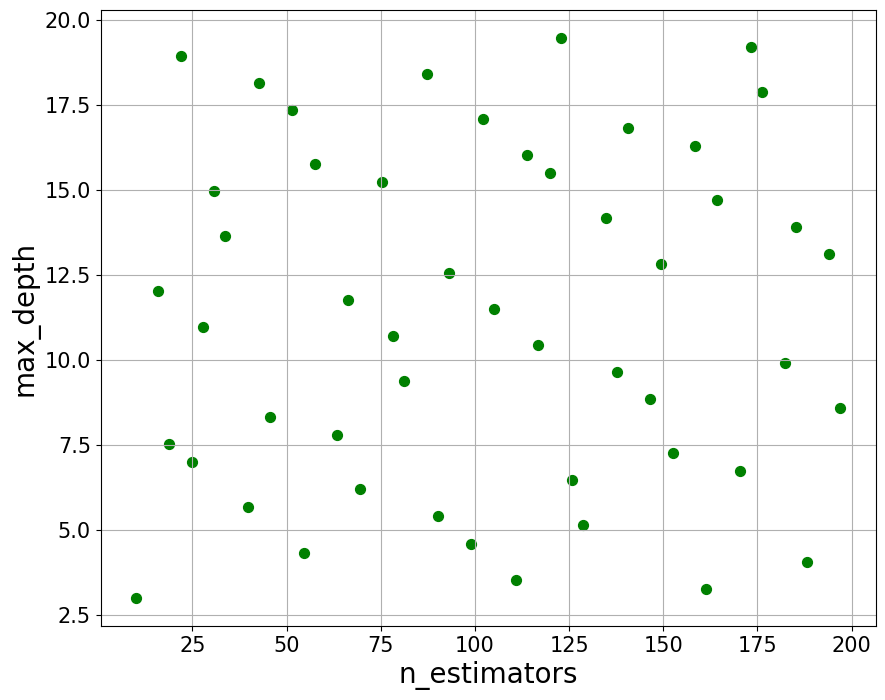

Sampled hyperparameter visualization saved to sampled_hyperparameters_sobol.png


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.datasets import load_iris
from scipy.stats.qmc import Sobol
from tqdm import tqdm
from pathlib import Path

# Load dataset
data = load_iris()
X, y = data.data, data.target

# Define hyperparameter search space (normalized between 0 and 1)
param_space = {
    "n_estimators": (10, 200),  # Number of trees in the forest
    "max_depth": (3, 20),       # Maximum depth of the tree
    "min_samples_split": (2, 10) # Minimum number of samples to split a node
}

# Number of hyperparameter samples
n_samples = 50

# Sobol Sequence Sampling
sobol = Sobol(d=len(param_space), scramble=False)
samples = sobol.random(n_samples)

# Rescale the samples to the actual ranges of the hyperparameters
param_names = list(param_space.keys())
param_bounds = np.array([param_space[name] for name in param_names])
param_samples = param_bounds[:, 0] + samples * (param_bounds[:, 1] - param_bounds[:, 0])

# Evaluate each sampled point using cross-validation
best_score = -np.inf
best_params = None
results = []

# Progress bar with tqdm applied outside enumerate
for i, sample in enumerate(tqdm(param_samples, desc="Evaluating Hyperparameters")):
    params = {
        "n_estimators": int(sample[0]),
        "max_depth": int(sample[1]),
        "min_samples_split": int(sample[2])
    }
    
    # Create the RandomForest model with the sampled hyperparameters
    clf = RandomForestClassifier(
        n_estimators=params['n_estimators'], 
        max_depth=params['max_depth'], 
        min_samples_split=params['min_samples_split'], 
        random_state=42
    )
    
    # Evaluate the model using cross-validation
    score = np.mean(cross_val_score(clf, X, y, cv=3))
    
    # Save the result
    results.append((params, score))
    
    if score > best_score:
        best_score = score
        best_params = params

# Output the best hyperparameters and their score
print(f"Best Parameters: {best_params}")
print(f"Best Cross-Validation Score: {best_score:.4f}")

# Visualize the sampled hyperparameter points
fig, ax = plt.subplots(figsize=(10, 8))

# Scatter plot for 'n_estimators' vs 'max_depth'
ax.scatter(param_samples[:, 0], param_samples[:, 1], color='#008000', s=50, label='Sampled Points')
ax.set_xlabel('n_estimators', fontsize=20)
ax.set_ylabel('max_depth', fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=15)
ax.grid(True)

# Save the plot
output_dir = OUTPUT_DIR
output_path = Path(output_dir) / "sampled_hyperparameters_sobol.png"
plt.savefig(output_path, bbox_inches='tight', pad_inches=0)
plt.show()

print(f"Sampled hyperparameter visualization saved to {output_path}")